# 06 — Segment Contribution Analysis

## Objective

Identify which customer states, product categories and seller states contributed most to the May–July 2018 booked GMV decline.

Different analytical grains are used:

- **Customer state:** `order_sales`, because each order belongs to one customer state.
- **Product category and seller state:** `item_sales`, using allocated booked GMV to prevent order-level GMV duplication.

May 2018 is the recent peak and July 2018 is the latest complete comparison month.

In [0]:
from pyspark.sql import functions as F

order_sales = spark.table("workspace.olist.order_sales")
item_sales = spark.table("workspace.olist.item_sales")

may_date = "2018-05-01"
july_date = "2018-07-01"

In [0]:
customer_state_contribution = (
    order_sales
    .filter(F.col("purchase_month").isin(may_date, july_date))
    .groupBy("customer_state")
    .agg(
        F.sum(F.when(F.col("purchase_month") == may_date, F.col("booked_gmv"))
              .otherwise(0)).alias("may_gmv"),
        F.sum(F.when(F.col("purchase_month") == july_date, F.col("booked_gmv"))
              .otherwise(0)).alias("july_gmv"),
        F.countDistinct(F.when(F.col("purchase_month") == may_date, F.col("order_id")))
         .alias("may_orders"),
        F.countDistinct(F.when(F.col("purchase_month") == july_date, F.col("order_id")))
         .alias("july_orders")
    )
    .withColumn("gmv_change", F.col("july_gmv") - F.col("may_gmv"))
    .withColumn("order_change", F.col("july_orders") - F.col("may_orders"))
    .withColumn("may_aov", F.col("may_gmv") / F.col("may_orders"))
    .withColumn("july_aov", F.col("july_gmv") / F.col("july_orders"))
    .withColumn("aov_change", F.col("july_aov") - F.col("may_aov"))
)

In [0]:
total_gmv_change = (
    customer_state_contribution
    .agg(F.sum("gmv_change").alias("total_gmv_change"))
    .first()["total_gmv_change"]
)

customer_state_contribution = (
    customer_state_contribution
    .withColumn(
        "net_change_contribution_pct",
        F.col("gmv_change") / F.lit(total_gmv_change) * 100
    )
)

In [0]:
display(
    customer_state_contribution
    .select(
        "customer_state",
        F.round("may_gmv", 2).alias("may_gmv"),
        F.round("july_gmv", 2).alias("july_gmv"),
        F.round("gmv_change", 2).alias("gmv_change"),
        "may_orders", "july_orders", "order_change",
        F.round("aov_change", 2).alias("aov_change"),
        F.round("net_change_contribution_pct", 2).alias("net_change_contribution_pct")
    )
    .orderBy("gmv_change")
)

customer_state,may_gmv,july_gmv,gmv_change,may_orders,july_orders,order_change,aov_change,net_change_contribution_pct
SP,488645.74,375436.45,-113209.29,3182,2744,-438,-16.74,106.93
RJ,146373.95,119584.14,-26789.81,829,713,-116,-8.85,25.30
RS,60118.42,48622.57,-11495.85,351,311,-40,-14.93,10.86
MG,120566.49,110217.38,-10349.11,757,649,-108,10.56,9.78
SC,41778.76,37199.87,-4578.89,226,198,-28,3.02,4.33
GO,27869.24,24565.38,-3303.86,138,114,-24,13.53,3.12
MS,11059.73,8295.34,-2764.39,44,49,5,-82.06,2.61
MT,14789.90,12645.68,-2144.22,66,47,-19,44.97,2.03
DF,29198.37,27296.87,-1901.50,144,166,22,-38.33,1.80
PR,54483.62,54129.90,-353.72,311,316,5,-3.89,0.33


## Product category contribution

Order-level booked GMV is allocated across order items. Therefore, category contributions can be aggregated without duplicating the GMV of multi-item orders.

Item count and allocated GMV per item are included to distinguish category-volume changes from changes in item value.

In [0]:
category_contribution = (
    item_sales
    .filter(F.col("purchase_month").isin(may_date, july_date))
    .groupBy("product_category_name")
    .agg(
        F.sum(F.when(F.col("purchase_month") == may_date, F.col("allocated_booked_gmv"))
              .otherwise(0)).alias("may_gmv"),
        F.sum(F.when(F.col("purchase_month") == july_date, F.col("allocated_booked_gmv"))
              .otherwise(0)).alias("july_gmv"),
        F.count(F.when(F.col("purchase_month") == may_date, 1)).alias("may_items"),
        F.count(F.when(F.col("purchase_month") == july_date, 1)).alias("july_items"),
        F.countDistinct(F.when(F.col("purchase_month") == may_date, F.col("order_id")))
         .alias("may_orders"),
        F.countDistinct(F.when(F.col("purchase_month") == july_date, F.col("order_id")))
         .alias("july_orders")
    )
    .withColumn("gmv_change", F.col("july_gmv") - F.col("may_gmv"))
    .withColumn("item_change", F.col("july_items") - F.col("may_items"))
    .withColumn("order_change", F.col("july_orders") - F.col("may_orders"))
    .withColumn("may_gmv_per_item", F.col("may_gmv") / F.col("may_items"))
    .withColumn("july_gmv_per_item", F.col("july_gmv") / F.col("july_items"))
    .withColumn(
        "gmv_per_item_change",
        F.col("july_gmv_per_item") - F.col("may_gmv_per_item")
    )
)

In [0]:
total_category_change = (
    category_contribution
    .agg(F.sum("gmv_change").alias("total_gmv_change"))
    .first()["total_gmv_change"]
)

category_contribution = (
    category_contribution
    .withColumn(
        "net_change_contribution_pct",
        F.col("gmv_change") / F.lit(total_category_change) * 100
    )
)

In [0]:
display(
    category_contribution
    .withColumn(
        "may_gmv_per_item",
        F.try_divide(F.col("may_gmv"), F.col("may_items"))
    )
    .withColumn(
        "july_gmv_per_item",
        F.try_divide(F.col("july_gmv"), F.col("july_items"))
    )
    .withColumn(
        "gmv_per_item_change",
        F.col("july_gmv_per_item") - F.col("may_gmv_per_item")
    )
    .select(
        "product_category_name",
        F.round("may_gmv", 2).alias("may_gmv"),
        F.round("july_gmv", 2).alias("july_gmv"),
        F.round("gmv_change", 2).alias("gmv_change"),
        "may_items", "july_items", "item_change",
        "may_orders", "july_orders", "order_change",
        F.round("gmv_per_item_change", 2).alias("gmv_per_item_change"),
        F.round("net_change_contribution_pct", 2).alias("net_change_contribution_pct")
    )
    .orderBy("gmv_change")
    .limit(15)
)

product_category_name,may_gmv,july_gmv,gmv_change,may_items,july_items,item_change,may_orders,july_orders,order_change,gmv_per_item_change,net_change_contribution_pct
relogios_presentes,132617.95,106064.72,-26553.23,636,528,-108,596,514,-82,-7.64,25.08
cama_mesa_banho,85126.8,68476.02,-16650.78,746,621,-125,605,515,-90,-3.84,15.73
brinquedos,36296.96,20360.84,-15936.12,220,154,-66,213,148,-65,-32.77,15.05
bebes,39327.99,27116.42,-12211.57,244,216,-28,223,208,-15,-35.64,11.53
ferramentas_jardim,43119.3,31122.9,-11996.4,291,179,-112,230,154,-76,25.69,11.33
instrumentos_musicais,20537.04,9309.49,-11227.55,61,36,-25,59,32,-27,-78.08,10.61
informatica_acessorios,59865.73,50169.63,-9696.1,462,424,-38,408,386,-22,-11.25,9.16
cool_stuff,33932.76,24660.1,-9272.66,176,117,-59,169,115,-54,17.97,8.76
eletronicos,21019.14,11777.32,-9241.82,233,152,-81,221,143,-78,-12.73,8.73
moveis_escritorio,25354.99,16928.89,-8426.1,105,81,-24,83,63,-20,-32.48,7.96


## Seller state contribution

Allocated booked GMV is aggregated by seller state to identify whether the decline was concentrated in specific supply-side regions.

In [0]:
seller_state_contribution = (
    item_sales
    .filter(F.col("purchase_month").isin(may_date, july_date))
    .groupBy("seller_state")
    .agg(
        F.sum(F.when(F.col("purchase_month") == may_date, F.col("allocated_booked_gmv"))
              .otherwise(0)).alias("may_gmv"),
        F.sum(F.when(F.col("purchase_month") == july_date, F.col("allocated_booked_gmv"))
              .otherwise(0)).alias("july_gmv"),
        F.count(F.when(F.col("purchase_month") == may_date, 1)).alias("may_items"),
        F.count(F.when(F.col("purchase_month") == july_date, 1)).alias("july_items"),
        F.countDistinct(F.when(F.col("purchase_month") == may_date, F.col("order_id")))
         .alias("may_orders"),
        F.countDistinct(F.when(F.col("purchase_month") == july_date, F.col("order_id")))
         .alias("july_orders")
    )
    .withColumn("gmv_change", F.col("july_gmv") - F.col("may_gmv"))
    .withColumn("item_change", F.col("july_items") - F.col("may_items"))
    .withColumn("order_change", F.col("july_orders") - F.col("may_orders"))
    .withColumn("may_gmv_per_item", F.try_divide(F.col("may_gmv"), F.col("may_items")))
    .withColumn("july_gmv_per_item", F.try_divide(F.col("july_gmv"), F.col("july_items")))
    .withColumn(
        "gmv_per_item_change",
        F.col("july_gmv_per_item") - F.col("may_gmv_per_item")
    )
)

In [0]:
total_seller_state_change = (
    seller_state_contribution
    .agg(F.sum("gmv_change").alias("total_gmv_change"))
    .first()["total_gmv_change"]
)

seller_state_contribution = (
    seller_state_contribution
    .withColumn(
        "net_change_contribution_pct",
        F.try_divide(
            F.col("gmv_change"),
            F.lit(total_seller_state_change)
        ) * 100
    )
)

In [0]:
display(
    seller_state_contribution
    .select(
        "seller_state",
        F.round("may_gmv", 2).alias("may_gmv"),
        F.round("july_gmv", 2).alias("july_gmv"),
        F.round("gmv_change", 2).alias("gmv_change"),
        "may_items", "july_items", "item_change",
        "may_orders", "july_orders", "order_change",
        F.round("gmv_per_item_change", 2).alias("gmv_per_item_change"),
        F.round("net_change_contribution_pct", 2).alias("net_change_contribution_pct")
    )
    .orderBy("gmv_change")
)

seller_state,may_gmv,july_gmv,gmv_change,may_items,july_items,item_change,may_orders,july_orders,order_change,gmv_per_item_change,net_change_contribution_pct
SP,772549.54,640072.41,-132477.13,5873,4872,-1001,5039,4291,-748,-0.16,125.13
RJ,79044.57,59472.82,-19571.75,401,354,-47,352,319,-33,-29.12,18.49
GO,8643.5,5693.82,-2949.68,46,37,-9,34,34,0,-34.02,2.79
MG,74586.02,72474.63,-2111.39,487,466,-21,464,429,-35,2.37,1.99
ES,4253.23,2417.84,-1835.39,15,14,-1,13,12,-1,-110.85,1.73
PE,14209.94,13259.27,-950.67,79,39,-40,68,37,-31,160.11,0.9
PB,1542.9,1056.15,-486.75,3,3,0,3,3,0,-162.25,0.46
MT,803.66,725.63,-78.03,5,6,1,5,6,1,-39.79,0.07
PI,131.56,94.65,-36.91,1,1,0,1,1,0,-36.91,0.03
RN,0.0,41.98,41.98,0,1,1,0,1,1,null,-0.04


## Top declining segments

The three segment dimensions represent alternative views of the same GMV change. Their contributions should be interpreted separately and must not be added together.

In [0]:
customer_plot = (
    customer_state_contribution
    .filter(F.col("gmv_change") < 0)
    .orderBy("gmv_change")
    .limit(8)
    .select("customer_state", "gmv_change")
    .toPandas()
)

category_plot = (
    category_contribution
    .filter(F.col("gmv_change") < 0)
    .orderBy("gmv_change")
    .limit(10)
    .select("product_category_name", "gmv_change")
    .toPandas()
)

seller_plot = (
    seller_state_contribution
    .filter(F.col("gmv_change") < 0)
    .orderBy("gmv_change")
    .limit(8)
    .select("seller_state", "gmv_change")
    .toPandas()
)

for data in [customer_plot, category_plot, seller_plot]:
    data["gmv_change"] = data["gmv_change"].astype(float)

category_plot["product_category_name"] = (
    category_plot["product_category_name"]
    .str.replace("_", " ")
    .str.title()
)

/Workspace/Users/erenkilicli99@gmail.com/2. Aşama/olist-sales-performance-investigation/reports/figures


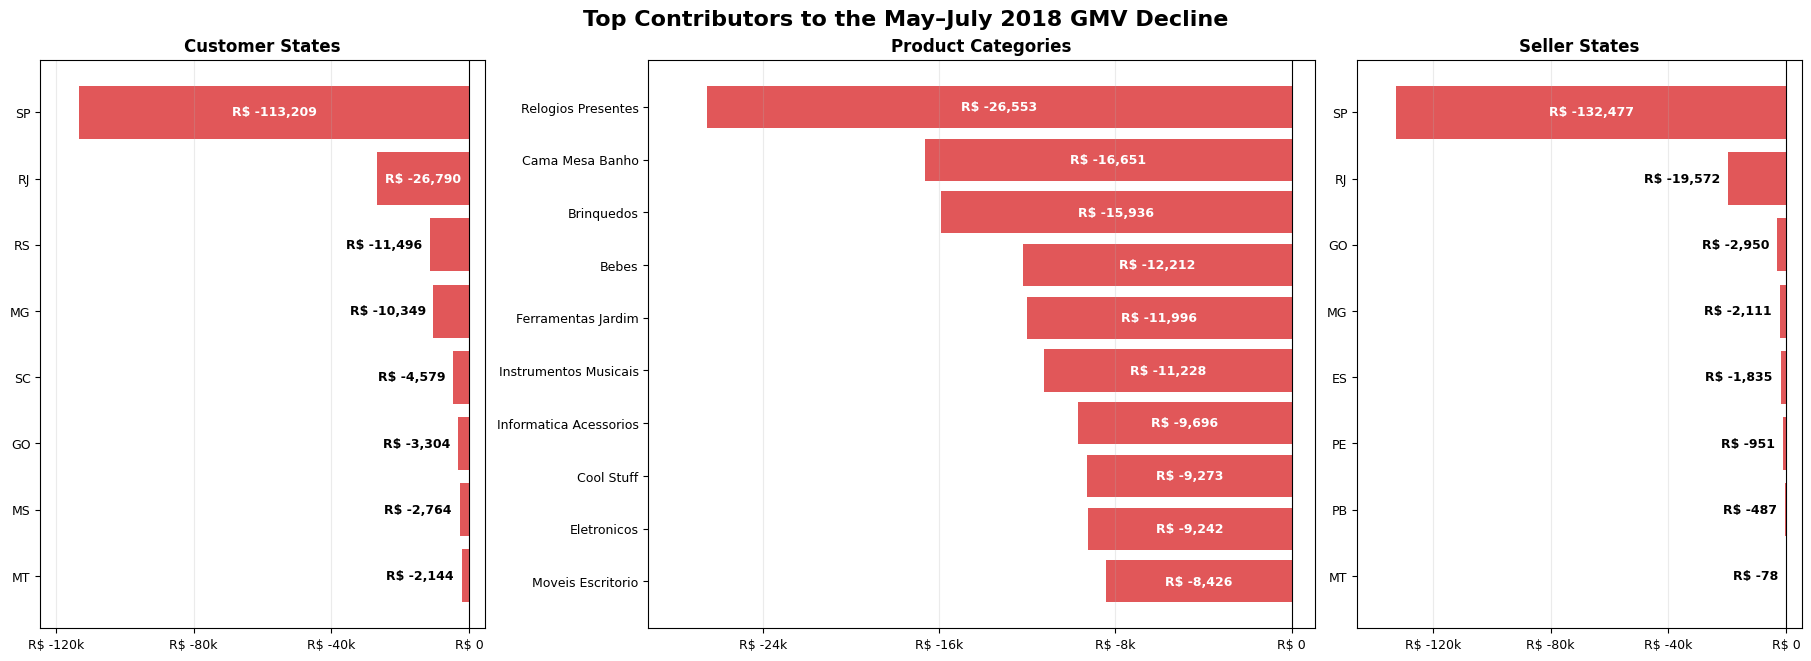

In [0]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from pathlib import Path

current_dir = Path.cwd()
repo_root = current_dir.parent if current_dir.name == "notebooks" else current_dir

figure_dir = repo_root / "reports" / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

print(figure_dir)

def brl_compact(value, position):
    if abs(value) >= 1_000:
        return f"R$ {value / 1_000:.0f}k"
    return f"R$ {value:.0f}"

def plot_segment_decline(ax, data, segment_column, title):
    bars = ax.barh(
        data[segment_column],
        data["gmv_change"],
        color="#E15759"
    )

    max_value = data["gmv_change"].abs().max()

    ax.invert_yaxis()
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlim(-max_value * 1.10, max_value * 0.04)
    ax.xaxis.set_major_locator(mtick.MaxNLocator(nbins=4))
    ax.xaxis.set_major_formatter(mtick.FuncFormatter(brl_compact))
    ax.tick_params(axis="both", labelsize=9)
    ax.grid(axis="x", alpha=0.25)

    for bar, value in zip(bars, data["gmv_change"]):
        large_bar = abs(value) >= max_value * 0.18

        if large_bar:
            label_x = value / 2
            label_color = "white"
            alignment = "center"
        else:
            label_x = value - max_value * 0.02
            label_color = "black"
            alignment = "right"

        ax.text(
            label_x,
            bar.get_y() + bar.get_height() / 2,
            f"R$ {value:,.0f}",
            ha=alignment,
            va="center",
            color=label_color,
            fontsize=9,
            fontweight="bold"
        )

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6.5),
    gridspec_kw={"width_ratios": [0.9, 1.35, 0.9]},
    constrained_layout=True
)

plot_segment_decline(
    axes[0],
    customer_plot,
    "customer_state",
    "Customer States"
)

plot_segment_decline(
    axes[1],
    category_plot,
    "product_category_name",
    "Product Categories"
)

plot_segment_decline(
    axes[2],
    seller_plot,
    "seller_state",
    "Seller States"
)

fig.suptitle(
    "Top Contributors to the May–July 2018 GMV Decline",
    fontsize=16,
    fontweight="bold"
)

fig.savefig(
    figure_dir / "segment_contributors.png",
    dpi=180,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

### Segment contribution findings

- The decline was geographically concentrated in São Paulo. Customer GMV from SP decreased by approximately R$113K between May and July 2018.
- On the seller side, SP-based sellers recorded the largest decline, approximately R$132K.
- The product decline was distributed across several categories, led by watches and gifts, bed and bath products, toys, baby products, and garden tools.
- The category results indicate a broad reduction in order and item volume rather than a decline caused by a single product category.
- Customer state, product category, and seller state are alternative views of the same GMV change. Their contributions overlap and must not be added together.

In [0]:
ratio_columns = [
    "may_gmv_per_item",
    "july_gmv_per_item",
    "gmv_per_item_change"
]

category_contribution = (
    category_contribution
    .drop(*ratio_columns)
    .withColumn(
        "may_gmv_per_item",
        F.try_divide(F.col("may_gmv"), F.col("may_items"))
    )
    .withColumn(
        "july_gmv_per_item",
        F.try_divide(F.col("july_gmv"), F.col("july_items"))
    )
    .withColumn(
        "gmv_per_item_change",
        F.col("july_gmv_per_item") - F.col("may_gmv_per_item")
    )
)

seller_state_contribution = (
    seller_state_contribution
    .drop(*ratio_columns)
    .withColumn(
        "may_gmv_per_item",
        F.try_divide(F.col("may_gmv"), F.col("may_items"))
    )
    .withColumn(
        "july_gmv_per_item",
        F.try_divide(F.col("july_gmv"), F.col("july_items"))
    )
    .withColumn(
        "gmv_per_item_change",
        F.col("july_gmv_per_item") - F.col("may_gmv_per_item")
    )
)

In [0]:
customer_state_contribution.write.mode("overwrite").option(
    "overwriteSchema", "true"
).saveAsTable("workspace.olist.customer_state_contribution")

category_contribution.write.mode("overwrite").option(
    "overwriteSchema", "true"
).saveAsTable("workspace.olist.category_contribution")

seller_state_contribution.write.mode("overwrite").option(
    "overwriteSchema", "true"
).saveAsTable("workspace.olist.seller_state_contribution")

In [0]:
from pathlib import Path
import shutil

current_dir = Path.cwd()

source_root = (
    current_dir.parent
    if current_dir.name == "notebooks"
    else current_dir
)

git_root = (
    source_root.parent
    / "olist-sales-performance-investigation-git"
)

items_to_copy = ["notebooks", "reports", ".gitignore"]

print("Source:", source_root)
print("Target:", git_root)

if not git_root.exists():
    raise FileNotFoundError(f"Git folder not found: {git_root}")

for item_name in items_to_copy:
    source = source_root / item_name
    destination = git_root / item_name

    if source.is_dir():
        shutil.copytree(
            source,
            destination,
            dirs_exist_ok=True
        )
        print(f"Copied folder: {item_name}")
    elif source.is_file():
        shutil.copy2(source, destination)
        print(f"Copied file: {item_name}")
    else:
        print(f"Not found: {source}")

print("\nGit folder contents:")

for item in sorted(git_root.iterdir()):
    print(item.name)

Source: /Workspace/Users/erenkilicli99@gmail.com/2. Aşama/olist-sales-performance-investigation
Target: /Workspace/Users/erenkilicli99@gmail.com/2. Aşama/olist-sales-performance-investigation-git
Copied folder: notebooks
Copied folder: reports
Copied file: .gitignore

Git folder contents:
.git
.gitignore
LICENSE
README.md
notebooks
reports
